In [9]:
import os
import scipy.io as sio
import numpy as np
import torch
import math
import trimesh
import k3d
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.io import loadmat
from torch.utils import data
from enum import Enum
import numpy.linalg as LA

In [10]:
# Base directory for Chair category
chair_dir = "dropbox/Chair"

# Subfolders
folders = ["boxes", "labels", "models", "obbs", "ops", "part mesh indices", "syms"]

# Check folder contents
for folder in folders:
    folder_path = os.path.join(chair_dir, folder)
    files = sorted(os.listdir(folder_path))
    print(f"\nFolder: {folder} | Number of files: {len(files)}")
    print("First 5 files:", files[:5])


Folder: boxes | Number of files: 6201
First 5 files: ['1.mat', '10.mat', '100.mat', '1000.mat', '1001.mat']

Folder: labels | Number of files: 6201
First 5 files: ['1.mat', '10.mat', '100.mat', '1000.mat', '1001.mat']

Folder: models | Number of files: 6201
First 5 files: ['1095.obj', '1127.obj', '1277.obj', '1282.obj', '1284.obj']

Folder: obbs | Number of files: 6201
First 5 files: ['1095.obb', '1127.obb', '1277.obb', '1282.obb', '1284.obb']

Folder: ops | Number of files: 6201
First 5 files: ['1.mat', '10.mat', '100.mat', '1000.mat', '1001.mat']

Folder: part mesh indices | Number of files: 6201
First 5 files: ['1.mat', '10.mat', '100.mat', '1000.mat', '1001.mat']

Folder: syms | Number of files: 6201
First 5 files: ['1.mat', '10.mat', '100.mat', '1000.mat', '1001.mat']


In [11]:
def explore_mat_file(file_path, description):
    """Helper function to explore .mat files"""
    print(f"{description} file path: {file_path}")
    mat_data = sio.loadmat(file_path)
    print(f"Keys in .mat file: {mat_data.keys()}")
    
    for key in mat_data:
        if not key.startswith("__"):
            print(f"{key} shape: {mat_data[key].shape}")
            print(mat_data[key])
    return mat_data

In [12]:
# boxes exploration
boxes_path = os.path.join(chair_dir, "boxes", sorted(os.listdir(os.path.join(chair_dir, "boxes")))[0])
boxes_mat = explore_mat_file(boxes_path, "Boxes")

# Extract and analyze boxes
boxes = boxes_mat['box']  # shape (12,3)
num_parts = boxes.shape[0] // 4

for i in range(num_parts):
    part_box = boxes[i*4:(i+1)*4]
    print(f"Part {i} box points:")
    print(part_box)

Boxes file path: dropbox/Chair/boxes/1.mat
Keys in .mat file: dict_keys(['__header__', '__version__', '__globals__', 'box'])
box shape: (12, 3)
[[ 0.0030865   0.00419755  0.0302842 ]
 [ 0.148677   -0.422335    0.488309  ]
 [ 0.0724135   0.169623   -0.315397  ]
 [ 0.223845    0.523685    0.781198  ]
 [ 0.805681    1.15351     0.305279  ]
 [ 0.890567    0.898086    0.89214   ]
 [ 0.         -0.0121707   0.0994548 ]
 [ 1.          0.770206    0.981659  ]
 [ 0.         -0.637679   -0.162646  ]
 [ 0.         -0.00438424 -0.00601635]
 [ 0.          0.637679    0.164046  ]
 [ 1.          0.77029     0.986434  ]]
Part 0 box points:
[[ 0.0030865   0.00419755  0.0302842 ]
 [ 0.148677   -0.422335    0.488309  ]
 [ 0.0724135   0.169623   -0.315397  ]
 [ 0.223845    0.523685    0.781198  ]]
Part 1 box points:
[[ 0.805681   1.15351    0.305279 ]
 [ 0.890567   0.898086   0.89214  ]
 [ 0.        -0.0121707  0.0994548]
 [ 1.         0.770206   0.981659 ]]
Part 2 box points:
[[ 0.         -0.637679   -0

In [13]:
# labels exploration
labels_path = os.path.join(chair_dir, "labels", sorted(os.listdir(os.path.join(chair_dir, "labels")))[0])
explore_mat_file(labels_path, "Labels")

Labels file path: dropbox/Chair/labels/1.mat
Keys in .mat file: dict_keys(['__header__', '__version__', '__globals__', 'label'])
label shape: (1, 3)
[[1 2 0]]


{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Tue Oct 15 15:09:20 2019',
 '__version__': '1.0',
 '__globals__': [],
 'label': array([[1, 2, 0]], dtype=uint8)}

In [14]:
# models exploration
models_path = os.path.join(chair_dir, "models", sorted(os.listdir(os.path.join(chair_dir, "models")))[0])
print("Model file path:", models_path)

# Load mesh
mesh = trimesh.load(models_path)
print(mesh)
print("Vertices shape:", mesh.vertices.shape)
print("Faces shape:", mesh.faces.shape)

Model file path: dropbox/Chair/models/1095.obj
<trimesh.Trimesh(vertices.shape=(29461, 3), faces.shape=(58918, 3))>
Vertices shape: (29461, 3)
Faces shape: (58918, 3)


In [15]:
# obbs exploration
obbs_path = os.path.join(chair_dir, "obbs", sorted(os.listdir(os.path.join(chair_dir, "obbs")))[0])
print("OBB file path:", obbs_path)

with open(obbs_path, 'r') as f:
    lines = f.readlines()

print(f"First 20 lines of {os.path.basename(obbs_path)}:")
for line in lines[:20]:
    print(line.strip())

OBB file path: dropbox/Chair/obbs/1095.obb
First 20 lines of 1095.obb:
N 3
0.0302842 0.488309 -0.315397 -0.995024 0.0971271 -0.0222212 -0.00601635 0.164046 0.986434 0.0994548 0.981659 -0.162646 0.89214 0.305279 0.781198
0.00419755 -0.422335 0.169623 0.999916 0.0121707 -0.00438424 -0.0121707 0.770206 -0.637679 -0.00438424 0.637679 0.77029 0.898086 0.523685 1.15351
0.0030865 0.148677 0.0724135 1 0 0 0 1 0 0 0 1 0.890567 0.223845 0.805681
C 2
0 2
1 2
S 0
L 3
0
2
1


In [16]:
# ops exploration
ops_path = os.path.join(chair_dir, "ops", sorted(os.listdir(os.path.join(chair_dir, "ops")))[0])
ops_mat = explore_mat_file(ops_path, "Ops")

for key in ops_mat:
    if not key.startswith("__"):
        print(f"{key} shape:", ops_mat[key].shape)
        print(ops_mat[key][:10])  # print first 10 entries

Ops file path: dropbox/Chair/ops/1.mat
Keys in .mat file: dict_keys(['__header__', '__version__', '__globals__', 'op'])
op shape: (1, 5)
[[0 0 1 0 1]]
op shape: (1, 5)
[[0 0 1 0 1]]


In [17]:
# part mesh indices exploration
part_mesh_path = os.path.join(chair_dir, "part mesh indices", sorted(os.listdir(os.path.join(chair_dir, "part mesh indices")))[0])
explore_mat_file(part_mesh_path, "Part mesh indices")

Part mesh indices file path: dropbox/Chair/part mesh indices/1.mat
Keys in .mat file: dict_keys(['__header__', '__version__', '__globals__', 'cell_boxs_correspond_objSerialNumber', 'shapename'])
cell_boxs_correspond_objSerialNumber shape: (1, 3)
[[array([[5, 6, 7, 8]], dtype=uint8) array([[ 9, 10]], dtype=uint8)
  array([[1, 2, 3, 4]], dtype=uint8)]]
shapename shape: (1,)
['1095']


{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Tue Oct 15 15:09:20 2019',
 '__version__': '1.0',
 '__globals__': [],
 'cell_boxs_correspond_objSerialNumber': array([[array([[5, 6, 7, 8]], dtype=uint8),
         array([[ 9, 10]], dtype=uint8),
         array([[1, 2, 3, 4]], dtype=uint8)]], dtype=object),
 'shapename': array(['1095'], dtype='<U4')}

In [18]:
# syms exploration
syms_path = os.path.join(chair_dir, "syms", sorted(os.listdir(os.path.join(chair_dir, "syms")))[0])
syms_mat = explore_mat_file(syms_path, "Syms")

for key in syms_mat:
    if not key.startswith("__"):
        print(f"{key} type: {type(syms_mat[key])}, shape: {getattr(syms_mat[key], 'shape', None)}")
        print(syms_mat[key])

Syms file path: dropbox/Chair/syms/1.mat
Keys in .mat file: dict_keys(['__header__', '__version__', '__globals__', 'shapename', 'sym'])
shapename shape: (1,)
['1095']
sym shape: (8, 1)
[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]]
shapename type: <class 'numpy.ndarray'>, shape: (1,)
['1095']
sym type: <class 'numpy.ndarray'>, shape: (8, 1)
[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]]


In [19]:
def get_box_corners(box_vec):
    """
    Convert 12-dim box vector to 8 corner points
    box_vec: 12 numbers -> center + dir0 + dir1 + dir2
    returns: 8x3 array of corner points
    """
    center = box_vec[0:3]
    dir0 = box_vec[3:6]
    dir1 = box_vec[6:9]
    dir2 = box_vec[9:12]

    dir0 = dir0 / LA.norm(dir0)
    dir1 = dir1 / LA.norm(dir1)
    dir2 = dir2 / LA.norm(dir2)

    # Half lengths along each axis
    d0 = 0.5 * dir0
    d1 = 0.5 * dir1
    d2 = 0.5 * dir2

    # Compute 8 corners
    corners = np.array([
        center - d0 - d1 - d2,
        center - d0 + d1 - d2,
        center + d0 - d1 - d2,
        center + d0 + d1 - d2,
        center - d0 - d1 + d2,
        center - d0 + d1 + d2,
        center + d0 - d1 + d2,
        center + d0 + d1 + d2,
    ])

    return corners

def plot_box(ax, corners, color='r'):
    """Plot a box in matplotlib 3D"""
    edges = [
        (0,1),(0,2),(1,3),(2,3),
        (4,5),(4,6),(5,7),(6,7),
        (0,4),(1,5),(2,6),(3,7)
    ]
    for i,j in edges:
        ax.plot([corners[i,0], corners[j,0]],
                [corners[i,1], corners[j,1]],
                [corners[i,2], corners[j,2]], color=color)

In [23]:
# Load a single box file for visualization
box_file = 'dropbox/Chair/boxes/1.mat'
boxes_mat = loadmat(box_file)
boxes = boxes_mat['box']  # shape (N_parts, 12)
print("Boxes shape:", boxes.shape)

Boxes shape: (12, 3)


In [22]:
def box_to_k3d_mesh(corners, color=0xFF0000):
    """
    Convert box corners to k3d mesh object
    corners: 8x3 array
    returns: k3d mesh object
    """
    # define faces of cube (12 triangles)
    faces = np.array([
        [0,1,2],[1,3,2],
        [4,5,6],[5,7,6],
        [0,1,4],[1,5,4],
        [2,3,6],[3,7,6],
        [0,2,4],[2,6,4],
        [1,3,5],[3,7,5]
    ], dtype=np.uint32)

    vertices = corners.astype(np.float32)
    indices = faces.flatten().astype(np.uint32)

    return k3d.mesh(vertices, indices, color=color, wireframe=True)

In [24]:
class Tree(object):
    class NodeType(Enum):
        BOX = 0
        ADJ = 1
        SYM = 2

    class Node(object):
        def __init__(self, box=None, left=None, right=None, node_type=None, sym=None, label=None):
            self.box = box
            self.sym = sym
            self.left = left
            self.right = right
            self.node_type = node_type
            self.label = label

        def is_leaf(self):
            return self.node_type == Tree.NodeType.BOX and self.box is not None

        def is_adj(self):
            return self.node_type == Tree.NodeType.ADJ

        def is_sym(self):
            return self.node_type == Tree.NodeType.SYM

    def __init__(self, boxes, ops, syms, labels):
        box_list = [b for b in torch.split(boxes, 1, 0)]
        sym_param = [s for s in torch.split(syms, 1, 0)]
        label_list = [l for l in labels[0]]
        box_list.reverse()
        sym_param.reverse()
        label_list.reverse()
        queue = []
        for id in range(ops.size()[1]):
            if ops[0, id] == Tree.NodeType.BOX.value:
                queue.append(Tree.Node(box=box_list.pop(), node_type=Tree.NodeType.BOX, label=label_list.pop()))
            elif ops[0, id] == Tree.NodeType.ADJ.value:
                left_node = queue.pop()
                right_node = queue.pop()
                queue.append(Tree.Node(left=left_node, right=right_node, node_type=Tree.NodeType.ADJ))
            elif ops[0, id] == Tree.NodeType.SYM.value:
                node = queue.pop()
                queue.append(Tree.Node(left=node, sym=sym_param.pop(), node_type=Tree.NodeType.SYM))
        assert len(queue) == 1
        self.root = queue[0]

class GRASSDataset(data.Dataset):
    def __init__(self, dir, models_num=0, transform=None):
        self.dir = dir
        num_examples = len(os.listdir(os.path.join(dir, 'ops')))
        self.transform = transform
        self.trees = []
        for i in range(models_num):
            boxes = torch.from_numpy(loadmat(os.path.join(dir, 'boxes', '%d.mat' % (i+1)))['box']).t().float()
            ops = torch.from_numpy(loadmat(os.path.join(dir, 'ops', '%d.mat' % (i+1)))['op']).int()
            syms = torch.from_numpy(loadmat(os.path.join(dir, 'syms', '%d.mat' % (i+1)))['sym']).t().float()
            labels = torch.from_numpy(loadmat(os.path.join(dir, 'labels', '%d.mat' % (i+1)))['label']).int()
            tree = Tree(boxes, ops, syms, labels)
            self.trees.append(tree)

    def __getitem__(self, index):
        return self.trees[index]

    def __len__(self):
        return len(self.trees)

In [29]:
def vrrotvec2mat(rotvector):
    """Convert rotation vector to rotation matrix"""
    s, c, t = math.sin(rotvector[3]), math.cos(rotvector[3]), 1 - math.cos(rotvector[3])
    x, y, z = rotvector[0], rotvector[1], rotvector[2]
    m = torch.FloatTensor([
        [t*x*x+c, t*x*y-s*z, t*x*z+s*y],
        [t*x*y+s*z, t*y*y+c, t*y*z-s*x],
        [t*x*z-s*y, t*y*z+s*x, t*z*z+c]
    ])
    return m

def decode_structure(root):
    """Decode the hierarchical structure into flat boxes"""
    syms = [torch.ones(8).mul(10)]
    stack = [root]
    boxes = []
    while stack:
        node = stack.pop()
        node_type = node.node_type.value
        if node_type == 1:  # ADJ
            stack.append(node.left)
            stack.append(node.right)
            s = syms.pop()
            syms.append(s)
            syms.append(s)
        if node_type == 2:  # SYM
            stack.append(node.left)
            syms.pop()
            syms.append(node.sym.squeeze(0))
        if node_type == 0:  # BOX
            reBox = node.box
            reBoxes = [reBox]
            s = syms.pop()
            l1, l2, l3 = abs(s[0]+1), abs(s[0]), abs(s[0]-1)
            # Symmetry/Translation/Reflection operations
            if l1 < 0.15:
                sList = torch.split(s, 1, 0)
                bList = torch.split(reBox.data.squeeze(0), 1, 0)
                f1 = torch.cat([sList[1], sList[2], sList[3]]); f1 = f1/torch.norm(f1)
                f2 = torch.cat([sList[4], sList[5], sList[6]])
                folds = round(1/s[7].item())
                for i in range(folds-1):
                    rotvector = torch.cat([f1, sList[7]*2*3.1415*(i+1)])
                    rotm = vrrotvec2mat(rotvector)
                    center = torch.cat([bList[0], bList[1], bList[2]])
                    dir0 = torch.cat([bList[3], bList[4], bList[5]])
                    dir1 = torch.cat([bList[6], bList[7], bList[8]])
                    dir2 = torch.cat([bList[9], bList[10], bList[11]])
                    newcenter = rotm.matmul(center - f2) + f2
                    newbox = torch.cat([newcenter, dir0, rotm.matmul(dir1), rotm.matmul(dir2)])
                    reBoxes.append(newbox)
            boxes.extend(reBoxes)
    return boxes

def draw(ax, p, color):
    """Draw a box in matplotlib 3D"""
    center = p[0:3]
    lengths = p[3:6]
    dir_1 = p[6:9] / LA.norm(p[6:9])
    dir_2 = p[9:12] / LA.norm(p[9:12])
    dir_3 = np.cross(dir_1, dir_2)
    dir_3 = dir_3 / LA.norm(dir_3)
    d1, d2, d3 = 0.5*lengths[0]*dir_1, 0.5*lengths[1]*dir_2, 0.5*lengths[2]*dir_3
    cornerpoints = np.array([
        center - d1 - d2 - d3, center - d1 + d2 - d3, center + d1 - d2 - d3, center + d1 + d2 - d3,
        center - d1 - d2 + d3, center - d1 + d2 + d3, center + d1 - d2 + d3, center + d1 + d2 + d3
    ])
    edges = [(0,1),(0,2),(1,3),(2,3),(4,5),(4,6),(5,7),(6,7),(0,4),(1,5),(2,6),(3,7)]
    for e in edges:
        ax.plot(*zip(cornerpoints[e[0]], cornerpoints[e[1]]), c=color)

def showGenshape(genshape):
    """Visualize generated shape using matplotlib"""
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_xlim(-0.7,0.7); ax.set_ylim(-0.7,0.7); ax.set_zlim(-0.7,0.7)
    cmap = plt.get_cmap('jet_r')
    for jj, box in enumerate(genshape):
        p = box.squeeze(0).numpy() if isinstance(box, torch.Tensor) else box
        draw(ax, p, cmap(float(jj)/len(genshape)))
    plt.show()

def decode_structure_with_labels(root):
    """Decode structure while preserving label information"""
    syms = [torch.ones(8).mul(10)]
    stack = [root]
    boxes = []
    labels = []

    while stack:
        node = stack.pop()
        node_type = node.node_type.value
        if node_type == 1:  # ADJ
            stack.append(node.left)
            stack.append(node.right)
            s = syms.pop()
            syms.append(s)
            syms.append(s)
        elif node_type == 2:  # SYM
            stack.append(node.left)
            syms.pop()
            syms.append(node.sym.squeeze(0))
        elif node_type == 0:  # BOX
            reBox = node.box
            reBoxes = [reBox]
            s = syms.pop()
            boxes.extend(reBoxes)
            labels.extend([node.label.item() for _ in reBoxes])  # store label
    return boxes, labels

def showGenshape_k3d_labels(boxes, labels):
    """Visualize boxes with color-coded labels in K3D"""
    plot = k3d.plot()
    unique_labels = sorted(set(labels))
    n_labels = len(unique_labels)
    cmap = plt.get_cmap('tab20')  # 20 distinct colors

    # Map each label to a k3d color
    label_to_color = {}
    for i, label in enumerate(unique_labels):
        r, g, b, _ = cmap(i / n_labels)
        color = (int(r*255) << 16) + (int(g*255) << 8) + int(b*255)
        label_to_color[label] = color

    for i, box in enumerate(boxes):
        p = box.squeeze(0).numpy() if isinstance(box, torch.Tensor) else box
        center = p[0:3]
        lengths = p[3:6]
        dir1 = p[6:9] / np.linalg.norm(p[6:9])
        dir2 = p[9:12] / np.linalg.norm(p[9:12])
        dir3 = np.cross(dir1, dir2)
        dir3 /= np.linalg.norm(dir3)
        d1, d2, d3 = 0.5*lengths[0]*dir1, 0.5*lengths[1]*dir2, 0.5*lengths[2]*dir3

        corners = np.array([
            center - d1 - d2 - d3,
            center - d1 + d2 - d3,
            center + d1 - d2 - d3,
            center + d1 + d2 - d3,
            center - d1 - d2 + d3,
            center - d1 + d2 + d3,
            center + d1 - d2 + d3,
            center + d1 + d2 + d3
        ])

        edges = [
            (0,1),(0,2),(1,3),(2,3),
            (4,5),(4,6),(5,7),(6,7),
            (0,4),(1,5),(2,6),(3,7)
        ]

        color = label_to_color[labels[i]]

        for start, end in edges:
            line_pts = np.vstack([corners[start], corners[end]]).astype(np.float32)
            plot += k3d.line(line_pts, shader='thick', width=0.01, color=color)

    plot.display()

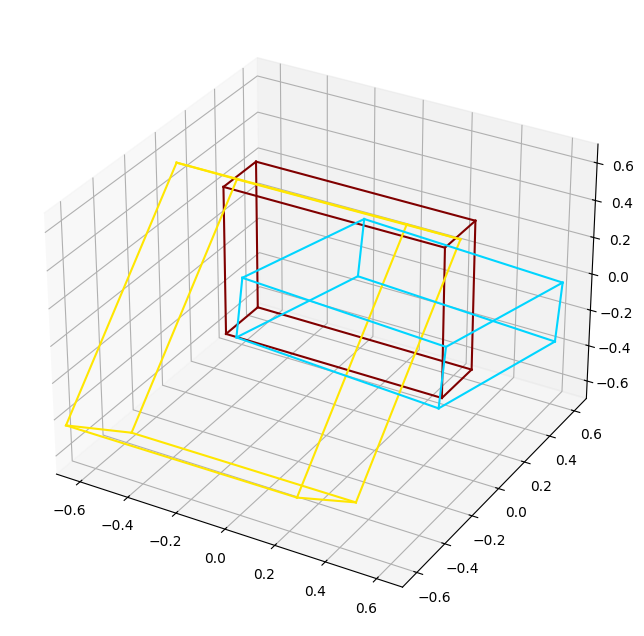

In [48]:
# Load and visualize one shape
dataset = GRASSDataset('dropbox/Chair', models_num=15)
tree = dataset[0]
boxes = decode_structure(tree.root)
showGenshape(boxes)

In [40]:
# Visualize with labels
boxes, labels = decode_structure_with_labels(tree.root)
showGenshape_k3d_labels(boxes, labels)

Output()

In [46]:
dataset[4]

In [49]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import os

# Cell 1: Create the widget controls
def create_shape_explorer_widget():
    # Get available categories from dropbox directory
    base_dir = 'dropbox'
    categories = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
    
    # Create widgets
    category_dropdown = widgets.Dropdown(
        options=categories,
        value='Bottle' if 'Bottle' in categories else categories[0],
        description='Category:',
        style={'description_width': 'initial'}
    )
    
    models_slider = widgets.IntSlider(
        value=1,
        min=1,
        max=50,  # Adjust based on your dataset size
        step=1,
        description='Model #:',
        continuous_update=False,
        style={'description_width': 'initial'}
    )
    
    visualize_button = widgets.Button(
        description='Visualize Shape',
        button_style='primary',
        tooltip='Click to visualize the selected shape'
    )
    
    output = widgets.Output()
    
    # Display widgets
    display(widgets.VBox([
        widgets.HBox([category_dropdown, models_slider]),
        visualize_button,
        output
    ]))
    
    def on_visualize_click(b):
        with output:
            clear_output(wait=True)
            try:
                category = category_dropdown.value
                model_num = models_slider.value
                
                print(f"Loading {category}, model #{model_num}...")
                
                # Load and visualize
                dataset = GRASSDataset(f'dropbox/{category}', models_num=model_num)
                if len(dataset) > 0:
                    tree = dataset[model_num - 1]  # -1 because slider starts at 1 but index at 0
                    boxes = decode_structure(tree.root)
                    showGenshape(boxes)
                    print(f"Successfully visualized {category} model #{model_num}")
                else:
                    print(f"No models found for {category}")
                    
            except Exception as e:
                print(f"Error: {e}")
                import traceback
                traceback.print_exc()
    
    visualize_button.on_click(on_visualize_click)
    
    # Return widgets for external access if needed
    return category_dropdown, models_slider, visualize_button, output

# Cell 2: Advanced version with more options
def create_advanced_shape_explorer_widget():
    # Get available categories
    base_dir = 'dropbox'
    categories = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
    
    # Create widgets
    category_dropdown = widgets.Dropdown(
        options=categories,
        value='Bottle' if 'Bottle' in categories else categories[0],
        description='Category:',
        style={'description_width': 'initial'}
    )
    
    models_slider = widgets.IntSlider(
        value=1,
        min=1,
        max=50,
        step=1,
        description='Model Index:',
        continuous_update=False,
        style={'description_width': 'initial'}
    )
    
    renderer_dropdown = widgets.Dropdown(
        options=['Matplotlib', 'K3D', 'K3D with Labels'],
        value='Matplotlib',
        description='Renderer:',
        style={'description_width': 'initial'}
    )
    
    auto_detect_checkbox = widgets.Checkbox(
        value=True,
        description='Auto-detect max models',
        style={'description_width': 'initial'}
    )
    
    visualize_button = widgets.Button(
        description='🚀 Visualize Shape',
        button_style='success',
        tooltip='Click to visualize the selected shape'
    )
    
    status_label = widgets.Label(value='Ready to visualize')
    output = widgets.Output()
    
    # Function to update max models based on category
    def update_max_models(change=None):
        if auto_detect_checkbox.value:
            try:
                category = category_dropdown.value
                ops_dir = os.path.join('dropbox', category, 'ops')
                if os.path.exists(ops_dir):
                    max_models = len([f for f in os.listdir(ops_dir) if f.endswith('.mat')])
                    models_slider.max = max(1, max_models)
                    status_label.value = f'Found {max_models} models in {category}'
                else:
                    status_label.value = f'No ops directory found for {category}'
            except Exception as e:
                status_label.value = f'Error detecting models: {e}'
    
    # Set up event handlers
    category_dropdown.observe(update_max_models, names='value')
    auto_detect_checkbox.observe(update_max_models, names='value')
    
    # Initial update
    update_max_models()
    
    # Display widgets
    controls = widgets.VBox([
        widgets.HBox([category_dropdown, models_slider]),
        widgets.HBox([renderer_dropdown, auto_detect_checkbox]),
        visualize_button,
        status_label,
        output
    ])
    
    display(controls)
    
    def on_visualize_click(b):
        with output:
            clear_output(wait=True)
            try:
                category = category_dropdown.value
                model_idx = models_slider.value
                renderer = renderer_dropdown.value
                
                status_label.value = f'Loading {category}, model #{model_idx}...'
                
                # Load dataset
                dataset = GRASSDataset(f'dropbox/{category}', models_num=model_idx)
                if len(dataset) > 0:
                    tree = dataset[model_idx - 1]
                    boxes = decode_structure(tree.root)
                    
                    # Choose renderer
                    if renderer == 'Matplotlib':
                        showGenshape(boxes)
                    elif renderer == 'K3D':
                        showGenshape_k3d(boxes)
                    elif renderer == 'K3D with Labels':
                        boxes, labels = decode_structure_with_labels(tree.root)
                        showGenshape_k3d_labels(boxes, labels)
                    
                    status_label.value = f'Successfully visualized {category} model #{model_idx}'
                    print(f"Rendered using: {renderer}")
                    
                else:
                    status_label.value = f'No models found for {category}'
                    print("No models available")
                    
            except Exception as e:
                status_label.value = f'Error: {e}'
                print(f"Error: {e}")
                import traceback
                traceback.print_exc()
    
    visualize_button.on_click(on_visualize_click)
    
    return {
        'category': category_dropdown,
        'model_index': models_slider,
        'renderer': renderer_dropdown,
        'auto_detect': auto_detect_checkbox,
        'button': visualize_button,
        'status': status_label,
        'output': output
    }

# Cell 3: Simple usage example
# print("Simple Shape Explorer:")
# create_shape_explorer_widget()

# Cell 4: Advanced usage example (uncomment to use)
print("\nAdvanced Shape Explorer:")
widget_controls = create_advanced_shape_explorer_widget()

# Cell 5: If you need the K3D visualization functions, make sure they're defined:
def showGenshape_k3d(genshape):
    """K3D visualization function"""
    plot = k3d.plot()
    for jj, box in enumerate(genshape):
        p = box.squeeze(0).numpy() if isinstance(box, torch.Tensor) else box
        center = p[0:3]
        lengths = p[3:6]
        dir1 = p[6:9] / np.linalg.norm(p[6:9])
        dir2 = p[9:12] / np.linalg.norm(p[9:12])
        dir3 = np.cross(dir1, dir2)
        dir3 = dir3 / np.linalg.norm(dir3)
        d1, d2, d3 = 0.5*lengths[0]*dir1, 0.5*lengths[1]*dir2, 0.5*lengths[2]*dir3

        corners = np.array([
            center - d1 - d2 - d3,
            center - d1 + d2 - d3,
            center + d1 - d2 - d3,
            center + d1 + d2 - d3,
            center - d1 - d2 + d3,
            center - d1 + d2 + d3,
            center + d1 - d2 + d3,
            center + d1 + d2 + d3
        ])

        edges = [
            (0,1),(0,2),(1,3),(2,3),
            (4,5),(4,6),(5,7),(6,7),
            (0,4),(1,5),(2,6),(3,7)
        ]

        for start, end in edges:
            line_pts = np.vstack([corners[start], corners[end]]).astype(np.float32)
            line = k3d.line(line_pts, shader='thick', width=0.01)
            plot += line

    plot.display()


Advanced Shape Explorer:
